# Polynomial Regression

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ujjwal091/ai-ml-course/blob/main/modules/01-supervised-learning/02-polynomial-regression/notes.ipynb)

*[Linear Regression](../01-linear-regression/01-basics/notes.ipynb) assumes the relationship between features and
target is a straight line. This module is about what to do when it visibly isn't — and the tradeoff that comes
with fixing it.*


## 1. When a straight line isn't enough

Linear Regression's core assumption is linearity: each feature relates to the target along a straight line. Real
relationships often don't cooperate — electricity or energy consumption vs. year (an S-curve), sales vs.
advertising spend (diminishing returns), blood pressure vs. BMI. Fitting a straight line to a curved relationship
doesn't just fit imperfectly — it *structurally* can't capture the shape, no matter how the line's slope and
intercept are tuned.

**How to tell:** plot the feature against the target, or look at the residuals of a linear fit — a visible curve
or pattern in either one is the signal.


## 2. The idea — transform the features, not the model

Instead of feeding a model raw $x$, feed it $x$ raised to increasing powers:

$$
\phi(x) = [1, x, x^2, x^3, \ldots, x^d]
$$

then fit ordinary Linear Regression on these transformed features:

$$
\hat{y} = w_0 + w_1 x + w_2 x^2 + w_3 x^3 + \cdots + w_d x^d
$$

> **Key insight:** this is still *linear* regression — linear in the parameters $w$. The curve comes entirely
> from the transformed features, not from a fundamentally different model, which means the exact same
> cost-function-and-gradient-descent machinery from Linear Regression applies completely unchanged.

| Degree | Equation | Shape |
|---|---|---|
| 1 | $w_0 + w_1 x$ | straight line — plain Linear Regression |
| 2 | $w_0 + w_1 x + w_2 x^2$ | parabola |
| 3 | $w_0 + w_1 x + w_2 x^2 + w_3 x^3$ | cubic, one inflection point |
| $n$ | … | increasingly flexible — and increasingly prone to overfitting |


## 3. Worked example — US primary energy consumption vs. year

Real, public data from Our World in Data: US total primary energy consumption, 1965–2024 — a genuine
non-linear growth curve (rapid growth, then a plateau).


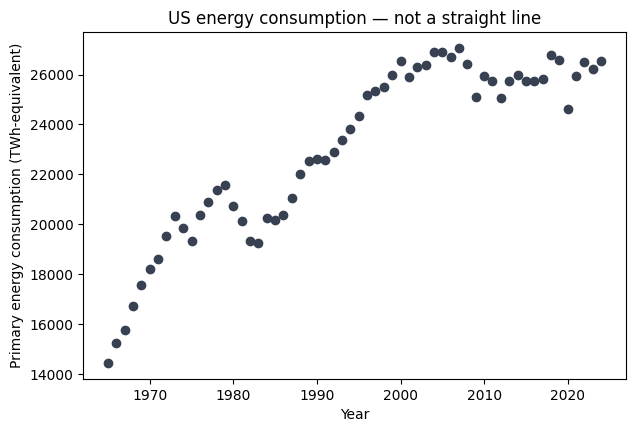

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn import metrics

ENERGY_URL = "https://raw.githubusercontent.com/owid/energy-data/master/owid-energy-data.csv"
ENERGY_PATH = "data/us-energy-consumption.csv"

if not os.path.exists(ENERGY_PATH):
    os.makedirs("data", exist_ok=True)
    energy_df = pd.read_csv(ENERGY_URL)
    us_energy = energy_df[energy_df['country'] == 'United States'][['year', 'primary_energy_consumption']].dropna()
    us_energy.to_csv(ENERGY_PATH, index=False)

energy = pd.read_csv(ENERGY_PATH).reset_index(drop=True)
plt.figure(figsize=(7, 4.5))
plt.scatter(energy['year'], energy['primary_energy_consumption'], color="#374151")
plt.xlabel("Year"); plt.ylabel("Primary energy consumption (TWh-equivalent)")
plt.title("US energy consumption — not a straight line")
plt.show()

In [2]:
# every 5th point held out as a simple test split
size = len(energy.index)
test_idx = range(0, size, 5)
train = energy[~energy.index.isin(test_idx)]
test = energy[energy.index.isin(test_idx)]

X_train = train['year'].values.reshape(-1, 1)
y_train = train['primary_energy_consumption']
X_test = test['year'].values.reshape(-1, 1)
y_test = test['primary_energy_consumption']

print(f"Train: {len(train)} rows | Test: {len(test)} rows")

Train: 48 rows | Test: 12 rows


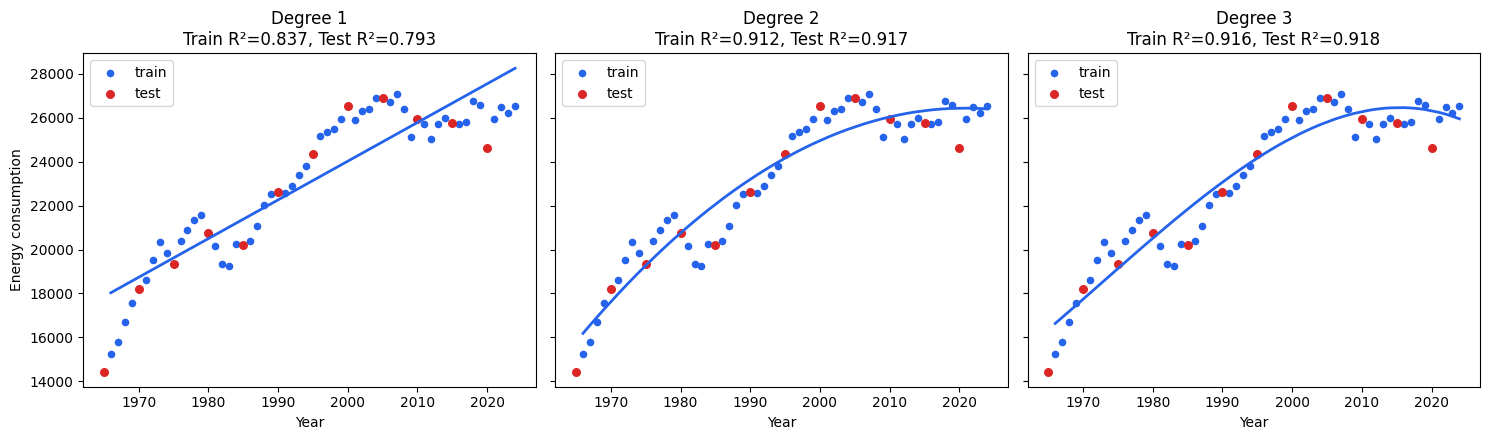

Degree 1: Train R² = 0.837, Test R² = 0.793
Degree 2: Train R² = 0.912, Test R² = 0.917
Degree 3: Train R² = 0.916, Test R² = 0.918


In [3]:
degrees = [1, 2, 3]
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=True)
r2_train, r2_test = [], []

for ax, degree in zip(axes, degrees):
    pipeline = Pipeline([
        ('poly', PolynomialFeatures(degree=degree)),
        ('model', LinearRegression())
    ])
    pipeline.fit(X_train, y_train)

    tr = metrics.r2_score(y_train, pipeline.predict(X_train))
    te = metrics.r2_score(y_test, pipeline.predict(X_test))
    r2_train.append(tr); r2_test.append(te)

    order = np.argsort(X_train.flatten())
    ax.scatter(X_train, y_train, color="#2563EB", s=20, label="train")
    ax.plot(X_train[order], pipeline.predict(X_train)[order], color="#2563EB", lw=2)
    ax.scatter(X_test, y_test, color="#DC2626", s=30, label="test")
    ax.set_title(f"Degree {degree}\nTrain R²={tr:.3f}, Test R²={te:.3f}")
    ax.set_xlabel("Year")
    ax.legend()

axes[0].set_ylabel("Energy consumption")
plt.tight_layout()
plt.show()

for d, tr, te in zip(degrees, r2_train, r2_test):
    print(f"Degree {d}: Train R² = {tr:.3f}, Test R² = {te:.3f}")

Degree 1 clearly misses the curvature — both R² scores land noticeably lower than degree 2. Degree 2 captures
the bend well. Degree 3 barely improves on degree 2 at all — extra complexity with nothing to show for it.

> **Lesson:** always evaluate on held-out test data to pick the degree. Here, degree 2 is the sweet spot;
> pushing further would start trading real fit for overfitting, which is exactly what the next section is about.


## 4. The Bias-Variance Tradeoff

Choosing a polynomial degree is a concrete instance of one of the most fundamental ideas in machine learning —
every model balances two competing failure modes.

**The student analogy:**

| | 😴 The under-studier (underfitting) | 🎓 The over-studier (overfitting) |
|---|---|---|
| What they did | Skimmed chapter headings | Memorized every practice question |
| Practice problems | Can't answer them | Perfect score |
| The real exam (new questions) | Fails | Fails — new phrasing throws them off |
| Train score | Low | High |
| Test score | Low | Low |

| Scenario | Train R² | Test R² | Problem |
|---|---|---|---|
| Underfitting | Low | Low | Model too simple — misses the real pattern |
| Overfitting | High | Low | Model too complex — memorized training noise |
| Just right | Good | Good | Generalizes to new data |

**In bias/variance terms:**

- **High bias, low variance** — consistently misses in the same wrong direction. Underfitting.
- **Low bias, high variance** — aims correctly on average but scatters wildly run to run. Overfitting.
- **Low bias, low variance** — the goal.
- **High bias, high variance** — the worst case, both problems compounding.


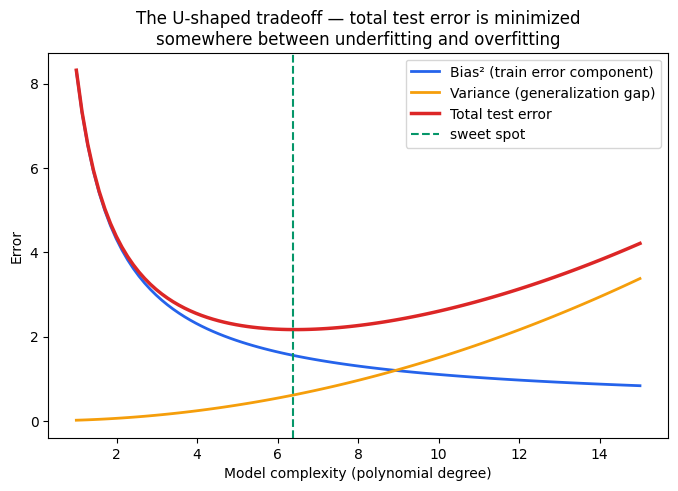

In [4]:
complexity = np.linspace(1, 15, 100)
bias_sq = 8 / complexity + 0.3
variance = 0.015 * complexity**2
total_error = bias_sq + variance

best_idx = np.argmin(total_error)

plt.figure(figsize=(8, 5))
plt.plot(complexity, bias_sq, color="#2563EB", lw=2, label="Bias² (train error component)")
plt.plot(complexity, variance, color="#F59E0B", lw=2, label="Variance (generalization gap)")
plt.plot(complexity, total_error, color="#DC2626", lw=2.5, label="Total test error")
plt.axvline(complexity[best_idx], color="#059669", ls="--", lw=1.5, label="sweet spot")
plt.xlabel("Model complexity (polynomial degree)")
plt.ylabel("Error")
plt.title("The U-shaped tradeoff — total test error is minimized\nsomewhere between underfitting and overfitting")
plt.legend()
plt.show()

**Connecting this back to polynomial degree specifically** — a model
$\hat{y} = w_0 + w_1x + w_2x^2 + w_3x^3 + w_4x^4$:

| Model | Non-zero weights | Complexity | Risk |
|---|---|---|---|
| Highest-degree | all of $w_1 \ldots w_4$ | highest | overfitting |
| Balanced | $w_1, w_2$ only | medium | — |
| Degree 1 | $w_1$ only | lowest | underfitting |

The more non-zero higher-order weights a model is allowed, the more it can contort itself to fit the training
data exactly — which is precisely what drives variance up and risks memorizing noise instead of the real trend.
That's exactly the degree-1-vs-2-vs-3 comparison above, generalized: this tradeoff isn't unique to polynomial
regression — it applies to model complexity in *any* algorithm.

> **The goal:** find the complexity where both train and test error are acceptably low — the generalization
> sweet spot where the model has learned the real pattern, not the noise.


## 5. Summary

- **Polynomial Regression** fixes a violated linearity assumption by transforming features into powers of
  themselves ($x, x^2, x^3, \ldots$), then fitting ordinary Linear Regression on the transformed features — it's
  still linear in the parameters, so nothing about the fitting machinery changes.
- **Degree selection** is a model-selection problem, not a math problem — always compare train vs. test R² across
  candidate degrees rather than picking by training fit alone.
- **The Bias-Variance Tradeoff** is the general principle underneath that choice: too simple underfits (high
  bias), too complex overfits (high variance), and the right complexity minimizes *test* error, not train error.

**Related (not yet covered in this repo):** Regularization (Ridge / Lasso — penalizing large weights directly, a
different way of controlling model complexity) and Cross-Validation (a more robust way to pick that complexity
than a single train/test split) tackle this same tradeoff from other angles.
